In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.nn.functional as F

In [2]:
#loading the dataset in pandas
splits = {'train': 'medium/train-00000-of-00001.parquet', 'validation': 'medium/validation-00000-of-00001.parquet', 'test': 'medium/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["train"])
df.to_csv("code.csv")
df.head()

C:\Users\divya\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,buggy,fixed
0,0,public static TYPE_1 init ( java.lang.String n...,public static TYPE_1 init ( java.lang.String n...
1,1,public TYPE_1 METHOD_1 ( java.lang.String name...,public TYPE_1 METHOD_1 ( java.lang.String name...
2,2,private boolean METHOD_1 ( TYPE_1 VAR_1 ) { bo...,private boolean METHOD_1 ( TYPE_1 VAR_1 ) { bo...
3,3,"public void METHOD_1 ( TYPE_1 VAR_1 , boolean ...","public void METHOD_1 ( TYPE_1 VAR_1 , boolean ..."
4,4,public boolean METHOD_1 ( ) { if ( ( VAR_1 ) =...,public boolean METHOD_1 ( ) { if ( ( VAR_1 ) >...


In [68]:
bugged = df["buggy"].to_list()
fixed = df['fixed'].to_list()
df.shape

(52364, 3)

In [22]:
# data preprocessing --> tokenization and padding
from collections import Counter
def tokenize(code):
    return code.split()
all_token = []
total_codes = bugged + fixed
for code in total_codes:
    all_token.extend(tokenize(code))

vocab = Counter(all_token)

word_idx = {"<pad>" : 0 , "<sos>" : 1 , "<eos>" : 2 , "<unk>" : 3}
for word , count in vocab.items():
    if count>=2:
        word_idx[word] = len(word_idx)

idx_word = {v: k for k ,v in word_idx.items()}

def encode_seq(code , word_idx , max_len = 80):
    tokens = ["<sos>"] + tokenize(code) + ["<eos>"]
    tokens = tokens[:max_len]
    ids = [word_idx.get(t , word_idx["<unk>"]) for t in tokens]
    ids+=[word_idx["<pad>"]] * ( max_len - len(ids))
    return ids

bugged_enc = [encode_seq(c,word_idx) for c in bugged]
fixed_enc = [encode_seq(c,word_idx) for c in fixed]

# Building a baseline encoder decoder model (LSTM)

In [69]:
class Encoder_LSTM(nn.Module):
    def __init__(self, vocab_size , emb_dim , hid_size , num_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.hid_size  = hid_size
        self.num_layers = num_layers
        self.emb = nn.Embedding(vocab_size , emb_dim)
        self.lstm = nn.LSTM(
            emb_dim ,
            hid_size,
            num_layers,
            batch_first = True,
            dropout = 0.5,
            bidirectional = True
        )
        self.fc = nn.Sequential(
            nn.Linear(2*hid_size , hid_size),
            nn.BatchNorm1d(hid_size),
        )
    def forward(self, x):
        x = self.emb(x)
        out , (h_c , c_c) = self.lstm(x)
        h_c = torch.cat([h_c[-2] , h_c[-1]] , dim = 1)
        c_c = torch.cat([c_c[-2] , c_c[-1]] , dim = 1)
        h_c = self.fc(h_c)
        c_c = self.fc(c_c)

        return out , h_c , c_c

In [70]:
class Decoder_LSTM(nn.Module):
    def __init__(self, vocab_size , emb_dim , hid_size , num_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.hid_size  = hid_size
        self.num_layers = num_layers
        self.emb = nn.Embedding(vocab_size , emb_dim)
        self.lstm = nn.LSTM(
            emb_dim , 
            hid_size ,
            num_layers ,
            batch_first = True,
            dropout = 0.5
        )
        self.linear = nn.Linear(hid_size , vocab_size)
    
    def forward(self, x , h_c , c_c ):
        x = self.emb(x).unsqueeze(1)
        out , (h_c , c_c) = self.lstm(x , (h_c , c_c))
        out = self.linear(out.squeeze(1))
        return out , h_c, c_c 
                       

In [71]:
import random
class Seq2Seq_LSTM(nn.Module):
    def __init__(self , encoder , decoder, device , word_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.word_idx = word_idx

    def forward(self , seq , target , teacher_forcing_ratio = 0.3):
        enc_out , h_c , c_c = self.encoder(seq)
        h_c = h_c.unsqueeze(0)
        c_c = c_c.unsqueeze(0)
        dec_inp = torch.full((seq.shape[0] , ) , self.word_idx["<sos>"] , dtype = torch.long).to(self.device)
        predictions = torch.zeros(seq.shape[0] , target.shape[1] , self.decoder.vocab_size).to(self.device)
        for t in range(1, target.shape[1]):
            pred , h_c , c_c = self.decoder(dec_inp , h_c , c_c )
            teacher_force = random.random() < teacher_forcing_ratio
            if teacher_force:
                dec_inp = target[: , t]
            else:
                dec_inp = pred.argmax(dim = 1)
            predictions[: , t , :] = pred
        return predictions
        

In [72]:
import time
def train_EncDec_LSTM(model , train_data , val_data , epochs = 20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    lossfnx = nn.CrossEntropyLoss(ignore_index= 0)
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4 , weight_decay = 1e-4)
    loss_train = []
    loss_val = []
    for epoch in range(epochs):
        model.train()
        total_loss_train = 0
        for i,(seq , target) in enumerate(train_data):
            
            seq , target = seq.to(device ) , target.to(device)
            optimizer.zero_grad()
            predict = model(seq , target , teacher_forcing_ratio = 0.3)
            #LLM used for shape mismatch
            output_dim = predict.shape[-1]
            predict_flattened = predict[:, 1:].reshape(-1, output_dim)
            target_flattened = target[:, 1:].reshape(-1)
            loss = lossfnx(predict_flattened, target_flattened)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            total_loss_train+=loss.item()
            optimizer.step()

        loss_train.append(total_loss_train/len(train_data))

        model.eval()
        with torch.no_grad():
            total_loss_val = 0
            for seq , target in val_data:
                seq , target = seq.to(device ) , target.to(device)
                predict = model(seq , target , teacher_forcing_ratio = 0.0)
                output_dim = predict.shape[-1]
                predict_flattened = predict[:, 1:].reshape(-1, output_dim)
                target_flattened = target[:, 1:].reshape(-1)
                loss = lossfnx(predict_flattened , target_flattened)
                total_loss_val+=loss.item()
            loss_val.append(total_loss_val/len(val_data))
        
        print(f"For Epoch {epoch+1} Training Loss: {total_loss_train/len(train_data):.2f} Validation Loss: {total_loss_val/len(val_data):.2f}")

    return loss_train , loss_val 


In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder_LSTM(len(word_idx), 128, 256, 3)
decoder = Decoder_LSTM(len(word_idx), 128, 256, 1)
model = Seq2Seq_LSTM(encoder, decoder, device, word_idx)

In [99]:
# creating dataset and dataloader
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self , seq , target ):
        self.seq = torch.tensor(seq , dtype = torch.long)
        self.target = torch.tensor(target , dtype = torch.long)
    def __len__(self):
        return len(self.seq)
    def __getitem__(self , idx):
        return self.seq[idx] , self.target[idx]
train_data = DataLoader(Data(bugged_enc,fixed_enc) , batch_size = 128 , shuffle =True)
val_data = DataLoader(Data(bugged_enc,fixed_enc) , batch_size = 128)

In [100]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [101]:
def predict(model , codes , word_idx , idx_word , max_len = 80 , device = 'cuda'):
    model.eval()
    results = []
    with torch.no_grad():
        for code in codes:
            tokens = encode_seq(code, word_idx, max_len)
            src = torch.tensor(tokens).unsqueeze(0).to(device)
            
            enc_out, h_c, c_c = model.encoder(src)
            h_c = h_c.unsqueeze(0)
            c_c = c_c.unsqueeze(0)
            
            dec_inp = torch.tensor([word_idx["<sos>"]]).to(device)
            generated = []
            
            for _ in range(max_len):
                pred, h_c, c_c = model.decoder(dec_inp, h_c, c_c)
                top_token = pred.argmax(dim=1)
                token_id = top_token.item()
                
                if token_id == word_idx["<eos>"]:
                    break
                generated.append(idx_word.get(token_id, "<unk>"))
                dec_inp = top_token
            results.append(" ".join(generated))
    return results

In [113]:
epoch = 20

In [ ]:
loss_train, loss_val = train_EncDec_LSTM(model, train_data, val_data, epochs=20)

For Epoch 1 Training Loss: 3.93 Validation Loss: 3.53
For Epoch 2 Training Loss: 3.30 Validation Loss: 3.49
For Epoch 3 Training Loss: 3.10 Validation Loss: 3.34
For Epoch 4 Training Loss: 2.96 Validation Loss: 3.29
For Epoch 5 Training Loss: 2.86 Validation Loss: 3.25
For Epoch 6 Training Loss: 2.78 Validation Loss: 3.24
For Epoch 7 Training Loss: 2.72 Validation Loss: 3.16
For Epoch 8 Training Loss: 2.67 Validation Loss: 3.16
For Epoch 9 Training Loss: 2.62 Validation Loss: 3.16
For Epoch 10 Training Loss: 2.58 Validation Loss: 3.14
For Epoch 11 Training Loss: 2.54 Validation Loss: 3.11
For Epoch 12 Training Loss: 2.51 Validation Loss: 3.09
For Epoch 13 Training Loss: 2.49 Validation Loss: 3.09
For Epoch 14 Training Loss: 2.47 Validation Loss: 3.09
For Epoch 15 Training Loss: 2.44 Validation Loss: 3.12
For Epoch 16 Training Loss: 2.43 Validation Loss: 3.07
For Epoch 17 Training Loss: 2.41 Validation Loss: 3.09
For Epoch 18 Training Loss: 2.39 Validation Loss: 3.12
For Epoch 19 Traini

In [103]:
# training dataset
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(

    bugged,
    fixed,
    test_size = 0.1,
    random_state= 42
)

In [104]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = predict(model , X_test , word_idx , idx_word , 80 , device)


In [106]:
print(y_test[1])
print(results[1])

public java.lang.String [ ] METHOD_1 ( ) { int VAR_1 = VAR_2 . METHOD_2 ( ) ; java.lang.String [ ] result = new java.lang.String [ VAR_1 ] ; for ( int i = 0 ; i < VAR_1 ; i ++ ) { result [ i ] = ( ( java.lang.String ) ( VAR_2 . METHOD_3 ( ) . METHOD_4 ( 0 , i ) ) ) ; } return result ; }

public java.lang.String [ ] METHOD_1 ( ) { java.lang.String VAR_1 = VAR_1 ; int VAR_2 = 0 ; int ( = 0 ; int [ ] VAR_2 = 0 ; for ( int i = 0 ; i < ( ; i ++ ) { VAR_1 . = ( . length ( ) ) ; i ++ ) { VAR_1 . METHOD_2 ( VAR_2 , VAR_3 ) ; }


In [107]:
# LLM for writing this function 
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

def evaluate_bleu(predictions, references):
    smoothing = SmoothingFunction().method1
    
    # corpus level BLEU
    refs = [[ref.split()] for ref in references]
    hyps = [pred.split() for pred in predictions]
    
    bleu1 = corpus_bleu(refs, hyps, weights=(1,0,0,0))
    bleu2 = corpus_bleu(refs, hyps, weights=(0.5,0.5,0,0))
    bleu4 = corpus_bleu(refs, hyps, weights=(0.25,0.25,0.25,0.25))
    
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")
    
    return bleu1, bleu2, bleu4

# usage
bleu1, bleu2, bleu4 = evaluate_bleu(results, y_test)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\divya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


BLEU-1: 0.6052
BLEU-2: 0.4693
BLEU-4: 0.2841


In [112]:
def token_accuracy(predictions, references):
    total_tokens = 0
    correct_tokens = 0
    
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        
        # compare up to the length of the shorter sequence
        min_len = min(len(pred_tokens), len(ref_tokens))
        correct_tokens += sum(1 for i in range(min_len) if pred_tokens[i] == ref_tokens[i])
        total_tokens += len(ref_tokens)
    
    accuracy = correct_tokens / total_tokens
    print(f"Token Accuracy (%): {accuracy*100:.2f}")
    return accuracy

token_accuracy(results , y_test)
print()

Token Accuracy (%): 23.15



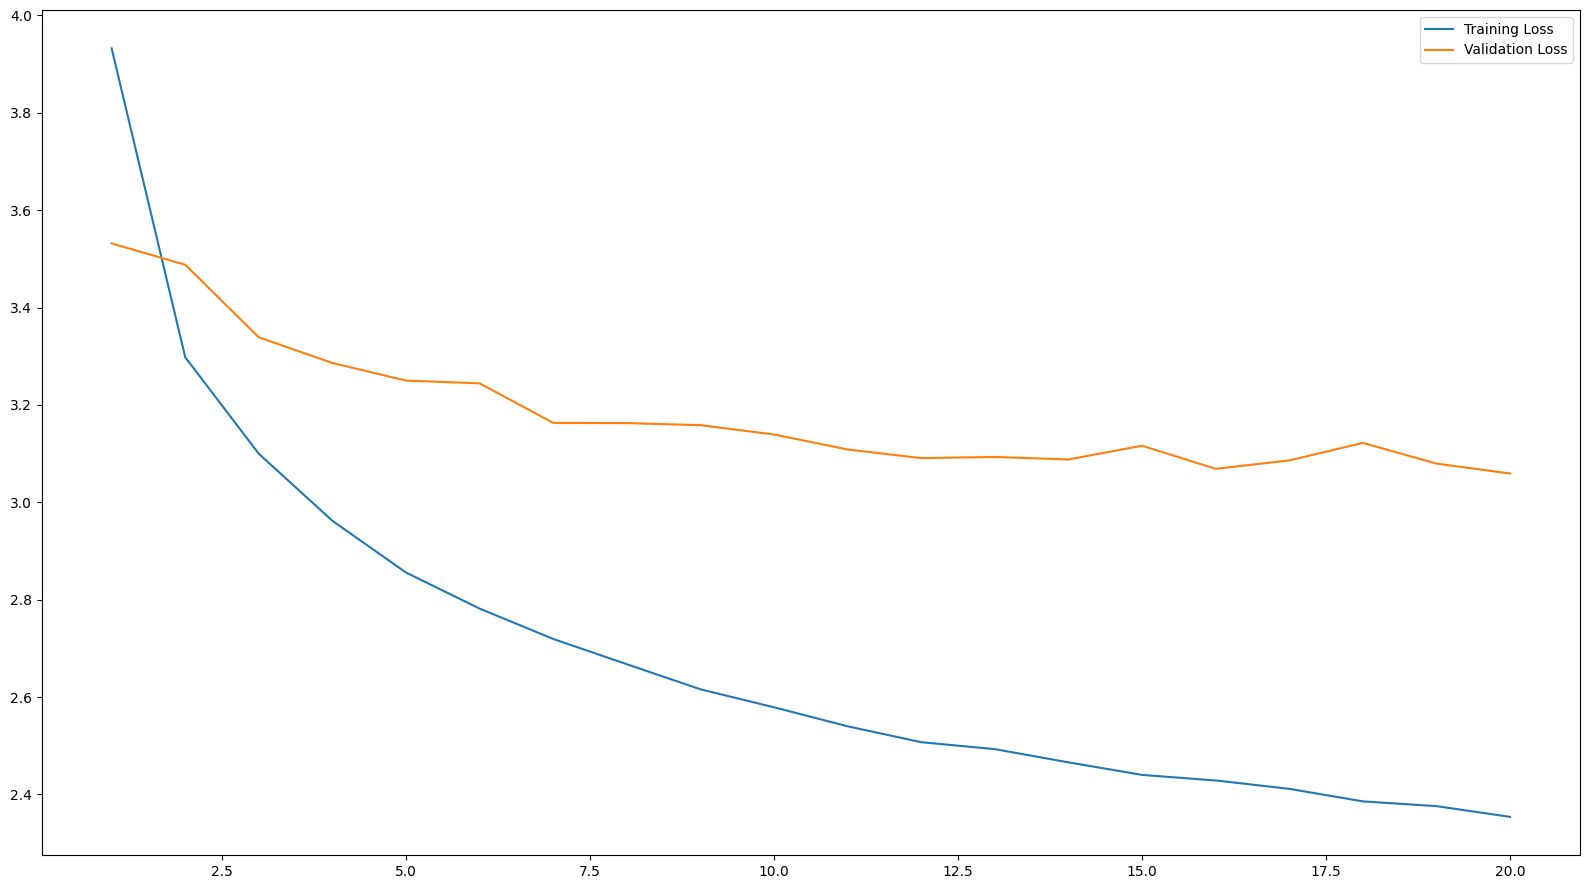

In [114]:
plt.figure(figsize = (16,9))
x = np.arange(1 , epoch+1)
plt.plot(x , loss_train , label = "Training Loss")
plt.plot(x , loss_val , label = "Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("T&VEncDecLSTM.png")